# A spiral is three things, and only one of them is a waveform

A Cartesian readout walks k-space on a grid. A spiral **turns**, and everything interesting about
it follows from the fact that the path and the timing are two separate questions:

| | |
|---|---|
| **the path** | the Nyquist condition and nothing else — adjacent turns of the *interleaved set* no further apart than `1/FOV`, so `dθ/dk_r = 2π·FOV(k_r)/shots`. No time appears in it |
| **the traversal** | how fast that curve may be taken: `\|g\| = v`, `\|g'\| = sqrt(a_t² + (κv²)²)`, swept forwards from rest and backwards from rest and minimised |
| **what the amplifier actually does** | the raster waveform, measured against the limits and corrected — and then `k` measured back off the built events, because that is what a reconstruction is handed |

Conflating the first two is the commonest way to get a spiral wrong, and the symptom is a readout
that **cannot be reversed**: integrate one ODE in time and the trajectory ends at full gradient, so
its time-reverse *begins* at full gradient, which is a waveform no block can start with. `v = 0` at
both ends is the design decision the whole module rests on, and it is what makes `'out'`, `'in'`,
`'in-out'` and `'out-in'` one class rather than four.

**Two passes**, as in [`../gre_epi_2d/`](../gre_epi_2d/01_build.ipynb): the readout on its own with
every number measured off it, then `GRESpiral2D` written out. `Spiral2D` ships; `GRESpiral2D` has
one consumer, which is this notebook, and stays here.

**Output:** six imaging `.seq` files, one Cartesian reference, and `seq/gre_spiral_2d_nominal.npz`.
**Needs nothing but `seqcraft`.**


## 0. The scanner, and the protocol

| | |
|---|---|
| **180 T/m/s** | a spiral is slew-limited throughout at this resolution — §1 measures that rather than assuming it — so the slew rate *is* the readout duration |
| **2.5 µs dwell** | 400 kHz over the whole receive chain. §5 finds the longest legal dwell, which is 3.06 µs, and this is the quantum below it |
| **`adc_samples_limit = 8192`** | the interpreter's limit, and the reason a single-shot arm needs three ADC events. Set explicitly, because pypulseq defaults it to "no limit" and a scanner does not |


In [1]:
from pathlib import Path
import contextlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc
from seqcraft.modules._support import oblique_trapezoid

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=180, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
    adc_samples_limit=8192,
)

FOV_MM = 220.0
MATRIX = 128
THICKNESS_MM = 3.0
DWELL_S = 2.5e-6                 # section 5 is why this one
SHOTS = 4                        # the interleaving every imaging file but `1shot`/`2shot` uses
VDS_DENSITY = (1.0, 0.5)         # half the FOV at the edge -- 70 % of the readout, same kmax
ECHOES = 3                       # the multi-echo file, for T2*
EXCITE_DURATION_S = 2.0e-3
SPOIL_CYCLES = 4.0
RF_SPOIL_DEG = 117.0
DUMMY_SHOTS = 2
FLIP_DEG = 30.0
TE_S = 20.0e-3                   # one echo time for every imaging file -- section 8
TR_S = 100.0e-3
REFERENCE_DTE_S = 2.46e-3        # fat/water in phase at 3 T; section 9 is why this number
REFERENCE_BANDWIDTH_HZ_PX = 600.0    # the shortest echo spacing has to be below 2.46 ms
REFERENCE_FLIP_DEG = 15.0
REFERENCE_TR_S = 30.0e-3
REFERENCE_DUMMIES = 30

DK_PER_M = 1e3 / FOV_MM
KMAX_PER_M = MATRIX / (2 * FOV_MM * 1e-3)
grad_raster = sc.Raster(opts.grad_raster_time)
block_raster = sc.Raster(opts.block_duration_raster)

SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)


def scanner(max_grad_mt_m=40.0, max_slew_t_m_s=180.0):
    """The same console with a different gradient amplifier, for the sweeps in section 1."""
    return pp.Opts(max_grad=max_grad_mt_m, grad_unit='mT/m',
                   max_slew=max_slew_t_m_s, slew_unit='T/m/s', B0=3.0,
                   rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6,
                   adc_samples_limit=8192)


def readout(**kwargs):
    """One `Spiral2D` at the reference protocol, with whatever this cell is varying."""
    base = dict(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, shots=SHOTS, dwell_s=DWELL_S)
    return sc.modules.Spiral2D(**{**base, **kwargs})


def compiled(tree, name='probe', definitions=None):
    """Compile, keeping the warnings so a cell can assert on them instead of hiding them.

    The vector-norm one is dropped: three spoiler axes ramping together exceed the bound the
    per-axis limits imply, routinely and legally, and every example here expects it.  A
    ``merge`` or a ``resample`` is what would be news, and neither is filtered.
    """
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always', sc.SeqCraftWarning)
        seq = sc.compile(tree, opts, name=name, definitions=definitions)
    return seq, [str(w.message) for w in caught
                 if issubclass(w.category, sc.SeqCraftWarning)
                 and 'vector-norm' not in str(w.message)]


def gradient_kinds(seq, axis):
    """Which pulseq representation `axis` came out as.  A split spiral must stay a ``grad``."""
    return sorted({getattr(g, 'type', '?') for i in range(1, len(seq.block_events) + 1)
                   for g in (getattr(seq.get_block(i), axis, None),) if g is not None})


spiral = readout()
print(f'{MATRIX} x {MATRIX} over {FOV_MM:.0f} mm, {THICKNESS_MM:.0f} mm slice')
print(f'dk {DK_PER_M:.4f} 1/m, kmax {KMAX_PER_M:.3f} 1/m, resolution {spiral.resolution_mm:.3f} mm')
print(f'{opts.max_grad / opts.gamma * 1e3:.0f} mT/m at {opts.max_slew / opts.gamma:.0f} T/m/s, '
      f'{opts.adc_dead_time * 1e6:.0f} us receive dead time')
print()
print(f'{SHOTS} interleaves: {spiral.turns:.1f} turns and {spiral.arm_duration_s * 1e3:.3f} ms an '
      f'arm, {spiral.num_samples} samples in {spiral.adc_segments} ADC event(s)')


128 x 128 over 220 mm, 3 mm slice
dk 4.5455 1/m, kmax 290.909 1/m, resolution 1.719 mm
40 mT/m at 180 T/m/s, 10 us receive dead time

4 interleaves: 16.0 turns and 13.230 ms an arm, 5292 samples in 1 ADC event(s)


---
# Pass 1 — the readout

## 1. The regime: at this protocol `max_grad` does nothing

The amplitude limit binds only beyond `max_grad²/max_slew`. Below that the trajectory never
reaches `max_grad` at all, because the *curvature* takes the whole slew budget first — so the
readout is slew-limited throughout and the peak gradient it does reach is `sqrt(max_slew·kmax)`.

That is the opposite of the Cartesian intuition, where a shorter readout means a bigger gradient.
It is a checkable claim, so it is swept rather than asserted.


In [2]:
threshold = opts.max_grad ** 2 / opts.max_slew
print(f'amplitude binds beyond max_grad^2/max_slew = {threshold:.1f} 1/m, and kmax is '
      f'{KMAX_PER_M:.1f} -> {"BELOW" if KMAX_PER_M < threshold else "ABOVE"} it')
print(f'so the peak should be sqrt(max_slew * kmax) = '
      f'{np.sqrt(opts.max_slew * KMAX_PER_M) / opts.gamma * 1e3:.2f} mT/m, whatever max_grad is')
print()

print(f'{"max_grad":>10s} {"arm":>10s} {"peak":>9s} {"peak slew":>11s}')
for grad_mt_m in (30.0, 40.0, 60.0, 80.0):
    probe = readout(opts=scanner(max_grad_mt_m=grad_mt_m))
    print(f'{grad_mt_m:8.0f}mT {probe.arm_duration_s * 1e3:9.3f}m '
          f'{probe.peak_grad_hz_m / opts.gamma * 1e3:8.2f} '
          f'{probe.peak_slew_hz_m_s / opts.gamma:10.1f}')
print('  30 mT/m is the row where amplitude binds; above the crossover nothing moves at all.')

print(f'\n{"max_slew":>10s} {"arm":>10s} {"1/sqrt predicts":>16s} {"peak":>9s}')
reference_arm = spiral.arm_duration_s
for slew_t_m_s in (90.0, 180.0, 360.0):
    probe = readout(opts=scanner(max_slew_t_m_s=slew_t_m_s))
    print(f'{slew_t_m_s:8.0f}T/s {probe.arm_duration_s * 1e3:9.3f}m '
          f'{reference_arm * np.sqrt(180.0 / slew_t_m_s) * 1e3:15.3f}m '
          f'{probe.peak_grad_hz_m / opts.gamma * 1e3:8.2f}')
print('  1/sqrt holds until the peak reaches max_grad, and the 360 T/m/s row is where it '
      'stops -- the crossover is at')
print(f'  sqrt(max_slew * kmax), which for 360 T/m/s is '
      f'{np.sqrt(2 * opts.max_slew * KMAX_PER_M) / opts.gamma * 1e3:.1f} mT/m and above the '
      f'amplifier.')
print()
print('`max_grad_hz_m` and `max_slew_hz_m_s` derate *below* the amplifier and never above it,')
print('which is why these rows build a scanner each: designing against more than the console')
print('has is not a design choice, it is a different console.')


amplitude binds beyond max_grad^2/max_slew = 378.5 1/m, and kmax is 290.9 -> BELOW it
so the peak should be sqrt(max_slew * kmax) = 35.07 mT/m, whatever max_grad is

  max_grad        arm      peak   peak slew
      30mT    13.630m    29.99      179.9


      40mT    13.230m    35.03      179.7
      60mT    13.230m    35.03      179.7


      80mT    13.230m    35.03      179.7
  30 mT/m is the row where amplitude binds; above the crossover nothing moves at all.

  max_slew        arm  1/sqrt predicts      peak
      90T/s    18.700m          18.710m    24.69


     180T/s    13.230m          13.230m    35.03
     360T/s     9.890m           9.355m    39.99
  1/sqrt holds until the peak reaches max_grad, and the 360 T/m/s row is where it stops -- the crossover is at
  sqrt(max_slew * kmax), which for 360 T/m/s is 49.6 mT/m and above the amplifier.

`max_grad_hz_m` and `max_slew_hz_m_s` derate *below* the amplifier and never above it,
which is why these rows build a scanner each: designing against more than the console
has is not a design choice, it is a different console.


## 2. The path: `density` is data

`density` is **the local FOV multiplier, sampled at equally spaced k-space radii** and interpolated
linearly. `(1.0,)` is Archimedean, `(1.0, 0.5)` halves the FOV at the edge, `(1.0, 1.0, 0.7, 0.33)`
holds Nyquist to a third of the radius and then tapers. Every number written *is* the thing it
controls, and one number has three exact readings:

| reading | value at `u` | what it answers |
|---|---|---|
| local FOV multiplier | `density(u)` | how wide an object this part of k-space encodes without aliasing |
| local undersampling `R(u)` | `1/density(u)` | what a parallel-imaging person would call the acceleration there |
| turn spacing, in `dk` | `1/density(u)` | how far apart the trajectory's turns are — the thing you measure off the plot |

The last two are the same number, which is the whole content of the Nyquist condition.

**Not polynomial coefficients**, which is what `vds.m` and most of the literature take. There the
curve written `(1.0, 0.5)` here is `(1.0, -0.5)`, and the natural-looking `(1.0, 0.5)` silently
means a FOV that *grows* to 330 mm — an oversampled outer ring, a readout 60 % longer, and nothing
raises. It reads as a slow design rather than as a typo.

The `spacing` column below is **measured off the built trajectory**, not read off the formula.


In [3]:
def dual(u, u0=0.4, r_edge=3.0):
    """Nyquist inside u0, then R rising smoothly to r_edge at the edge -- what a sequence cannot say."""
    t = np.clip((u - u0) / (1 - u0), 0.0, 1.0)
    return 1.0 / (1.0 + (r_edge - 1.0) * t ** 2)


DENSITIES = {
    '(1.0,)': (1.0,),
    '(1.0, 0.5)': (1.0, 0.5),
    '(1.0, 0.25)': (1.0, 0.25),
    '(1.0, 0.8, 0.25)': (1.0, 0.8, 0.25),
    '(1.0, 0.95, 0.75, 0.25)': (1.0, 0.95, 0.75, 0.25),
    '(1.0, 1.0, 0.7, 0.33)': (1.0, 1.0, 0.7, 0.33),
    'callable, smooth': dual,
}

probes = {label: readout(density=density) for label, density in DENSITIES.items()}
uniform = probes['(1.0,)']
print(f'{"density":24s} {"arc/arm":>9s} {"arm":>9s} {"vs uniform":>11s} {"R edge":>7s} '
      f'{"spacing at kmax":>16s} {"samples":>8s}')
for label, probe in probes.items():
    print(f'{label:24s} {probe.arc_length_per_m:8.0f} {probe.arm_duration_s * 1e3:8.3f}m '
          f'{probe.arm_duration_s / uniform.arm_duration_s:10.1%} '
          f'{probe.edge_undersampling:7.2f} {probe.worst_turn_gap_dk:14.3f}dk '
          f'{probe.num_samples:8d}')

print()
print('Rows 3 to 5 all reach R = 4 at the edge and differ only in how fast they get there --')
print('55 %, 64 % and 71 % of the uniform readout.  That trade is invisible from')
print('edge_undersampling alone, and it is the reason `density` is a curve rather than a number.')
print()
SHORT = ('uniform', '2 pt', '2 pt', '3 pt', '4 pt', 'Nyq 1/3', 'smooth')
print('R(u), asked for -- how much of k-space is actually Nyquist:')
print(f'{"u":>6s}' + ''.join(f'{name:>10s}' for name in SHORT))
for u in (0.0, 0.25, 0.5, 0.75, 1.0):
    print(f'{u:6.2f}' + ''.join(f'{FOV_MM / float(p.fov_mm_of(u)):10.2f}'
                               for p in probes.values()))
print('  The last two columns reach the same place: Nyquist out to a third of the radius and')
print('  R = 3 at the edge, one with four numbers and one with a function.  The callable buys')
print('  smoothness, not reach.')


density                    arc/arm       arm  vs uniform  R edge  spacing at kmax  samples
(1.0,)                      14631   13.230m     100.0%    1.00          1.000dk     5292
(1.0, 0.5)                   9758    9.300m      70.3%    2.00          1.970dk     3720
(1.0, 0.25)                  7322    7.340m      55.5%    4.00          3.682dk     2936
(1.0, 0.8, 0.25)             8601    8.520m      64.4%    4.00          3.563dk     3408
(1.0, 0.95, 0.75, 0.25)      9595    9.400m      71.1%    4.00          3.444dk     3760
(1.0, 1.0, 0.7, 0.33)        9779    9.570m      72.3%    3.03          2.821dk     3828
callable, smooth             9982    9.780m      73.9%    3.00          2.853dk     3912

Rows 3 to 5 all reach R = 4 at the edge and differ only in how fast they get there --
55 %, 64 % and 71 % of the uniform readout.  That trade is invisible from
edge_undersampling alone, and it is the reason `density` is a curve rather than a number.

R(u), asked for -- how much of k-s

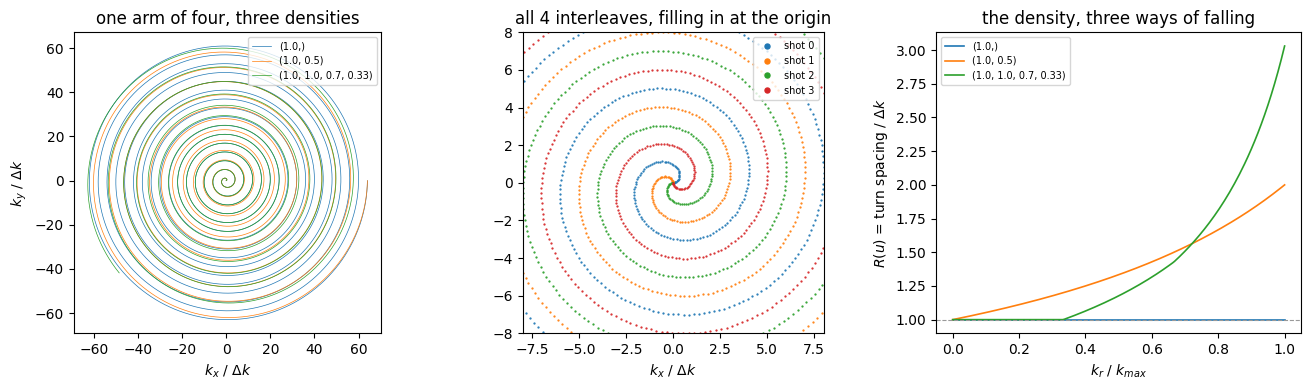

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
for label in ('(1.0,)', '(1.0, 0.5)', '(1.0, 1.0, 0.7, 0.33)'):
    k = probes[label].k_per_m(shot=0)
    axes[0].plot(k[0] / DK_PER_M, k[1] / DK_PER_M, lw=0.5, label=label)
axes[0].set(xlabel='$k_x$ / $\\Delta k$', ylabel='$k_y$ / $\\Delta k$', aspect='equal',
            title='one arm of four, three densities')
axes[0].legend(fontsize=7)

for interleaf in range(SHOTS):
    k = uniform.k_per_m(shot=interleaf)
    axes[1].plot(k[0] / DK_PER_M, k[1] / DK_PER_M, '.', ms=1.2, label=f'shot {interleaf}')
axes[1].set(xlabel='$k_x$ / $\\Delta k$', aspect='equal', xlim=(-8, 8), ylim=(-8, 8),
            title=f'all {SHOTS} interleaves, filling in at the origin')
axes[1].legend(fontsize=7, markerscale=6)

for label in ('(1.0,)', '(1.0, 0.5)', '(1.0, 1.0, 0.7, 0.33)'):
    u = np.linspace(0.0, 1.0, 200)
    axes[2].plot(u, FOV_MM / probes[label].fov_mm_of(u), lw=1.2, label=label)
axes[2].axhline(1.0, color='0.6', lw=0.8, ls='--')
axes[2].set(xlabel='$k_r$ / $k_{max}$', ylabel='$R(u)$ = turn spacing / $\\Delta k$',
            title='the density, three ways of falling')
axes[2].legend(fontsize=7)
fig.tight_layout()


## 3. The trajectory that plays

A Cartesian readout has to land its samples **on a grid**. A spiral has none, and a NUFFT is *told*
the positions — so the requirement is weaker in one direction and much stronger in the other:

> The trajectory does not have to land anywhere in particular. It has to be **known** — the array
> the module hands back has to be where the samples actually are, to a small fraction of `dk`.

`kmax` coming out 0.03 % low is a 0.03 % scaling of the resolution and nothing else. `k` reported
one gradient raster from where it played is a blur, a shading and a wrong field map. So `k_per_m`
is measured off the **built events** and checked against `sc.kspace`, which shares no code with it.


In [5]:
print(f'{"variant":9s} {"echoes":>7s} {"arms":>5s} {"blocks":>7s} {"samples":>8s} '
      f'{"|k - sc.kspace|":>16s} {"|k| at the end":>16s}  gx')
for variant, echoes in (('out', 1), ('out', 3), ('in', 1), ('in-out', 1), ('in-out', 2),
                        ('out-in', 2)):
    probe = readout(variant=variant, echoes=echoes)
    tree = sc.LogicBlock('readout').add(0.0, probe(shot=1))
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        measured = sc.kspace(tree, opts)
    seq, notes = compiled(tree)
    claimed = probe.k_per_m(shot=1)
    worst = float(np.abs(measured['k_adc'][:2] - claimed).max())
    residual = float(np.abs(measured['k'][:2, -1]).max())
    arms = len(probe.te_s) * (1 if variant in ('out', 'in') else 2)
    arms -= 2 if variant == 'out-in' else 0
    kinds = '+'.join(gradient_kinds(seq, 'gx'))
    print(f'{variant:9s} {echoes:7d} {arms:5d} {len(seq.block_events):7d} '
          f'{claimed.shape[1]:8d} {worst:14.2e}   {residual:14.2e}    {kinds}')
    assert not notes, notes

print()
print('1e-5 1/m is 3e-6 of one dk, and it is not a design error: it is pypulseq\'s own shape')
print('compression, which round-trips this waveform with a relative error of 5e-8 and says so')
print('twice per block.  Knowing a spiral\'s trajectory better than that through a .seq file is')
print('not possible, and it does not need to be.')
print()
print(f'built kmax {np.abs(spiral.k_per_m(shot=0)).max():.4f} against designed {KMAX_PER_M:.4f} '
      f'1/m ({np.hypot(*spiral.k_per_m(shot=0)).max() / KMAX_PER_M - 1:+.4%})')
print('Every gradient is a `grad`, including the split ones -- a spiral that came back as an')
print('extended trapezoid would have lost its own shape at a block boundary.')


variant    echoes  arms  blocks  samples  |k - sc.kspace|   |k| at the end  gx
out             1     1       1     5292       1.25e-05         2.20e-05    grad


out             3     3       3    15876       2.49e-05         5.61e-05    grad
in              1     1       1     5292       1.64e-05         2.20e-05    grad


in-out          1     2       2    10576       1.47e-05         7.27e-05    grad


in-out          2     4       3    21152       1.47e-05         7.27e-05    grad


out-in          2     2       2    10576       5.51e-12         1.34e-13    grad

1e-5 1/m is 3e-6 of one dk, and it is not a design error: it is pypulseq's own shape
compression, which round-trips this waveform with a relative error of 5e-8 and says so
twice per block.  Knowing a spiral's trajectory better than that through a .seq file is
not possible, and it does not need to be.

built kmax 290.9065 against designed 290.9091 1/m (-0.0009%)
Every gradient is a `grad`, including the split ones -- a spiral that came back as an
extended trapezoid would have lost its own shape at a block boundary.


## 4. Four variants, `echoes`, and why not eight modules

Write `a` for the designed arm, `k` running 0 → `kmax`, and `r` for its time-reverse. Reversing
time negates the gradient, so `r'(0) = -a'(T)` and `r'(T) = -a'(0)` — and because the arm was
designed to **arrive at rest**, both ends of both arms are at `g = 0` and every join is exactly
continuous with nothing between them.

That is the whole reason spiral in/out exists: its seam **is** `k = 0`, and `k = 0` can be put at
the spin echo. It is also why `echoes` needs no `polarity` beside it — the variant already carries
the monopolar/bipolar choice:

| | arms | between echoes | the Cartesian analogue |
|---|---|---|---|
| `'out'` | `a` × `echoes` | a **rewinder** back to the origin | `polarity='monopolar'` |
| `'in'` | `r` × `echoes` | a **prephaser** back out to `kmax` | `polarity='monopolar'` |
| `'in-out'` | `r a` × `echoes` | **nothing** | `polarity='bipolar'` |
| `'out-in'` | `a r` × (`echoes`−1) | **nothing** | `polarity='bipolar'` |

`'out-in'` acquires `k = 0` at each *end* rather than in the middle, so it cannot have fewer than
two echoes and its interior echoes get two arms' worth of data where its outer two get one. That is
the honest reason `'in-out'` is the symmetric multi-echo choice and `'out-in'` is the cheapest way
to get exactly two.


In [6]:
print(f'{"variant":9s} {"echoes":>7s} {"readout":>9s} {"echo spacing":>13s} {"ADC events":>11s} '
      f'{"samples/region":>15s}  te_s / ms')
for variant in ('out', 'in', 'in-out', 'out-in'):
    for echoes in (1, 2, 3):
        try:
            probe = readout(variant=variant, echoes=echoes)
        except sc.ConfigurationError as error:
            print(f'{variant:9s} {echoes:7d}  refused: {str(error).splitlines()[0]}')
            continue
        events = len(probe.t_adc_s) // probe.num_samples * probe.adc_segments
        spacing = f'{probe.echo_spacing_s * 1e3:12.3f}m' if echoes > 1 else f'{"-":>13s}'
        print(f'{variant:9s} {echoes:7d} {probe.readout_duration_s * 1e3:8.3f}m {spacing} '
              f'{events:11d} {probe.num_samples:15d}  '
              f'{np.round(np.array(probe.te_s) * 1e3, 2)}')

print()
print('The two two-arm variants pay nothing between echoes and the two one-arm variants pay a')
print(f'{readout(echoes=2).echo_spacing_s * 1e3 - spiral.arm_duration_s * 1e3:.3f} ms fly-back, '
      f'which is exactly the monopolar/bipolar trade a Cartesian')
print('multi-echo train makes -- at a spiral\'s scale.')


variant    echoes   readout  echo spacing  ADC events  samples/region  te_s / ms
out             1   13.630m             -           1            5292  [0.01]


out             2   27.250m       13.623m           2            5292  [1.000e-02 1.363e+01]
out             3   40.870m       13.623m           3            5292  [1.000e-02 1.363e+01 2.725e+01]


in              1   13.630m             -           1            5292  [13.62]
in              2   27.250m       13.620m           2            5292  [13.62 27.24]


in              3   40.870m       13.620m           3            5292  [13.62 27.24 40.86]
in-out          1   27.240m             -           2           10576  [13.62]


in-out          2   53.700m       26.462m           3           21152  [13.62 40.08]
in-out          3   80.160m       26.462m           4           31728  [13.62 40.08 66.54]
out-in          1  refused: variant='out-in' acquires k = 0 at each end, so it has at least two echoes.


out-in          2   26.480m       26.457m           2           10576  [1.000e-02 2.647e+01]
out-in          3   52.940m       26.460m           3           21152  [1.000e-02 2.647e+01 5.293e+01]

The two two-arm variants pay nothing between echoes and the two one-arm variants pay a


0.393 ms fly-back, which is exactly the monopolar/bipolar trade a Cartesian
multi-echo train makes -- at a spiral's scale.


## 5. The ADC: the guard, the divisor, and the split

`check_event_sizes` exists because of a spiral: *"nothing checked them until a 67 388-sample spiral
readout reached a scanner, which refused the block with `fRTEBFinish() failed for block type: ArbX
ArbY ADC`"*. Three constraints, and the module owns all three.

| | |
|---|---|
| **the guard** | one `adc_dead_time` before the receiver opens and after it closes, and **two** between consecutive ADC events of the same acquisition. So the sample count is not `duration/dwell` and never was |
| **the divisor** | pypulseq's timing check enforces `adc_samples_divisor` — 4 on Siemens. Nothing here had ever met it by accident, because every other readout picks a power-of-two sample count for its own reasons; a spiral picks its count from a *duration* |
| **the limit** | a single-shot arm is 20 964 samples against 8192, so it needs three events — and each seam is a **hole in the trajectory** |

`adc_segments` is a *recovery* and `shots` is the *answer*: `adc_segments=1` refuses rather than
splitting, and names the smallest `shots` that fits in one event.


In [7]:
one_shot = readout(shots=1)
print(f'{"shots":>6s} {"arm":>9s} {"samples":>8s} {"ADC events":>26s} {"k lost at a seam":>18s}')
for shots in (1, 2, 4, 8):
    probe = one_shot if shots == 1 else readout(shots=shots)
    lost = probe.peak_grad_hz_m * 2 * float(opts.adc_dead_time)
    print(f'{shots:6d} {probe.arm_duration_s * 1e3:8.3f}m {probe.num_samples:8d} '
          f'{str(probe.segment_samples):>26s} {lost / DK_PER_M:15.2f}dk')
print('  Two dead times per seam, not one: the receiver needs its guard before it opens as well')
print('  as after it closes.  An iterative reconstruction over four interleaves does not notice;')
print('  a single-shot gridding reconstruction does.')

print()
print(f'sample quantum = lcm(grad_raster/gcd(grad_raster, dwell), adc_samples_divisor) = '
      f'{sc.modules._support.sample_quantum(dwell_s=DWELL_S, opts=opts)}')
print(f'longest legal dwell = dwell / worst gap = '
      f'{DWELL_S / spiral.worst_sample_gap_dk * 1e6:.3f} us   (chosen {DWELL_S * 1e6:.1f} us, '
      f'worst gap {spiral.worst_sample_gap_dk:.3f} dk)')
print()
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always', sc.SeqCraftWarning)
    coarse = readout(dwell_s=6e-6)
print(f'a 6 us dwell warns rather than refusing -- {coarse.worst_sample_gap_dk:.2f} dk between '
      f'samples:')
print(f'  {str(caught[0].message).splitlines()[0]}')
print('  A warning because deliberate along-arm undersampling is a real choice, and the module')
print('  should not have an opinion about it.  Not knowing is what is not a choice.')


 shots       arm  samples                 ADC events   k lost at a seam
     1   52.450m    20964         (8192, 8192, 4580)            6.56dk


     2   26.290m    10508               (8192, 2316)            6.56dk


     4   13.230m     5292                    (5292,)            6.56dk


     8    6.710m     2684                    (2684,)            6.56dk
  Two dead times per seam, not one: the receiver needs its guard before it opens as well
  as after it closes.  An iterative reconstruction over four interleaves does not notice;
  a single-shot gridding reconstruction does.

sample quantum = lcm(grad_raster/gcd(grad_raster, dwell), adc_samples_divisor) = 4
longest legal dwell = dwell / worst gap = 3.060 us   (chosen 2.5 us, worst gap 0.817 dk)



a 6 us dwell warns rather than refusing -- 1.96 dk between samples:
  consecutive samples are up to 1.96 dk apart at a 6000 ns dwell, so the arm is undersampled along its own path; 3.061 us is the longest dwell that stays inside one dk.
  A warning because deliberate along-arm undersampling is a real choice, and the module
  should not have an opinion about it.  Not knowing is what is not a choice.


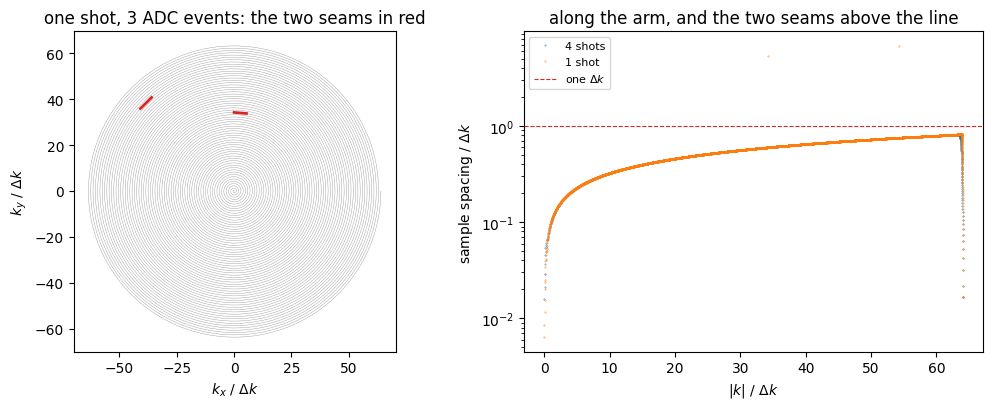

In [8]:
k = one_shot.k_per_m(shot=0)
at, holes = 0, []
for count in one_shot.segment_samples[:-1]:
    at += count
    holes.append((k[:, at - 1], k[:, at]))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].plot(k[0] / DK_PER_M, k[1] / DK_PER_M, lw=0.3, color='0.6')
for before, after in holes:
    axes[0].plot([before[0] / DK_PER_M, after[0] / DK_PER_M],
                 [before[1] / DK_PER_M, after[1] / DK_PER_M], color='C3', lw=2.0)
axes[0].set(xlabel='$k_x$ / $\\Delta k$', ylabel='$k_y$ / $\\Delta k$', aspect='equal',
            title=f'one shot, {len(one_shot.segment_samples)} ADC events: the two seams in red')

for label, probe in (('4 shots', spiral), ('1 shot', one_shot)):
    gap = np.abs(np.diff(probe.k_per_m(shot=0)[0] + 1j * probe.k_per_m(shot=0)[1]))
    axes[1].plot(np.abs(probe.k_per_m(shot=0)[0] + 1j * probe.k_per_m(shot=0)[1]) / DK_PER_M,
                 np.concatenate([gap, gap[-1:]]) / DK_PER_M, '.', ms=0.6, label=label)
axes[1].axhline(1.0, color='C3', lw=0.8, ls='--', label='one $\\Delta k$')
axes[1].set(xlabel='$|k|$ / $\\Delta k$', ylabel='sample spacing / $\\Delta k$', yscale='log',
            title='along the arm, and the two seams above the line')
axes[1].legend(fontsize=8)
fig.tight_layout()


## 6. Three wrong versions, because all three compile

None of these raises, none looks wrong in a plot, and each is a different kind of quiet.

| | what it costs |
|---|---|
| **anything laid beside the arm on its own axes** | an arbitrary gradient's samples sit at raster *centres* and a trapezoid's knots at raster *edges*; the compiler holds either exactly and their sum on neither, so it resamples and warns |
| **a join measured in isolation** | a raster-centre waveform is piecewise linear through its samples, so the segment from the previous piece's last sample to this one's first carries area the join does not count |
| **a naive per-axis prephaser** | two trapezoids stretched to a common duration each reach `max_slew`, and together ask for `sqrt(2)` times it. `check_limits` measures per axis and does not see it |


In [9]:
@contextlib.contextmanager
def uncorrected_joins():
    """Build with the join correction removed -- a design the module deliberately does not offer."""
    module = sc.modules.readout.spiral_2d
    original = module._correct_joins
    module._correct_joins = lambda waveform, joins, *, raster: waveform
    try:
        yield
    finally:
        module._correct_joins = original


# 1. an overlapping rephaser.  Designed against a derated slew so the sum has somewhere to go:
# at the full 180 T/m/s the spiral is already at the limit everywhere and anything added to it
# is refused by check_limits before the resampling fallback is reached, which is its own
# finding and a reassuring one.
soft = readout(max_slew_hz_m_s=90.0 * opts.gamma)
for area in (0.0, 10.0):
    tree = sc.LogicBlock('probe').add(0.0, soft(shot=0))
    if area:
        tree.add(2e-3, pp.make_trapezoid('x', area=area, duration=1e-3, system=opts))
    label = 'clean' if not area else f'a rephaser of {area:.0f} 1/m on x'
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always', sc.SeqCraftWarning)
        try:
            seq = sc.compile(tree, opts)
            outcome = f'compiled, gx {gradient_kinds(seq, "gx")}'
        except sc.CompilerContractError as error:
            outcome = 'REFUSED: ' + str(error).splitlines()[1].strip('- ')[:74]
    print(f'{label:26s} {outcome}')
    for note in caught:
        print(f'{"":28s}{str(note.message).splitlines()[0][:88]}')
print()
print('  The compiler holds an arbitrary gradient exactly and a trapezoid exactly and their')
print('  *sum* on neither, so it resamples onto the raster edges and says so -- and the')
print('  resample moves the area on that axis by 0.046 1/m.  Then the against-tree check')
print('  refuses it, which it can only do because its tolerance is scaled by the area the')
print('  axis *traversed* (9.3e-3 here) rather than by the net: on the net it would be at')
print('  its 1e-6 floor, where pypulseq\'s own shape compression already sits, and a legal')
print('  spiral would be refused for the same reason as an illegal one.')
print('  Either way the fix is the same: keep the readout\'s two axes clear inside its own')
print('  block.  The module puts its prephaser, fly-backs and rewinder *inside* the arm\'s')
print('  own waveform so that there is nothing to sum anywhere in the readout.')

# 2. the join measured in isolation.
print()
with uncorrected_joins():
    naive_join = readout()
for label, probe in (('corrected', spiral), ('in isolation', naive_join)):
    tree = sc.LogicBlock('probe').add(0.0, probe(shot=0))
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        residual = float(np.abs(sc.kspace(tree, opts)['k'][:2, -1]).max())
    print(f'a rewinder {label:14s} leaves |k| = {residual:10.3e} 1/m = {residual / DK_PER_M:.4f} dk')
print('  0.02 dk is invisible in every plot, and it is a phase ramp across the next image.')

# 3. the naive per-axis prephaser at 45 degrees.
print()
inward = readout(variant='in', prephase=False)
area = inward.k_start_per_m(shot=1) / np.sqrt(2) * np.sqrt(2)   # the shot-1 vector, at 45 degrees
area = np.array([KMAX_PER_M, KMAX_PER_M]) / np.sqrt(2)
per_axis = [pp.make_trapezoid(axis, area=component, system=opts)
            for axis, component in zip('xy', area)]
window = max(float(pp.calc_duration(g)) for g in per_axis)
per_axis = [pp.make_trapezoid(axis, area=component, duration=window, system=opts)
            for axis, component in zip('xy', area)]
together = oblique_trapezoid(area_per_m=area, opts=opts)
print(f'{"":16s} {"duration":>9s} {"vector peak":>12s} {"vector slew":>12s}')
for label, pair in (('per axis', per_axis), ('oblique_trapezoid', together)):
    peak = np.hypot(*[float(g.amplitude) for g in pair])
    print(f'{label:16s} {pp.calc_duration(*pair) * 1e6:8.1f}u '
          f'{peak / opts.gamma * 1e3:11.2f} {peak / float(pair[0].rise_time) / opts.gamma:11.2f}')
print(f'  against a {opts.max_slew / opts.gamma:.0f} T/m/s amplifier, and the first one compiles '
      f'cleanly.')
print('  oblique_trapezoid designs ONE trapezoid of area hypot(ax, ay) and splits it by direction')
print('  cosines, so the timing and the vector peak are the same at every angle.')


clean                      compiled, gx ['grad']
a rephaser of 10 1/m on x  REFUSED: axis x m0: compiled m0 10.0464 1/m differs from the tree sum 10 1/m -- a s

  The compiler holds an arbitrary gradient exactly and a trapezoid exactly and their
  *sum* on neither, so it resamples onto the raster edges and says so -- and the
  resample moves the area on that axis by 0.046 1/m.  Then the against-tree check
  refuses it, which it can only do because its tolerance is scaled by the area the
  axis *traversed* (9.3e-3 here) rather than by the net: on the net it would be at
  its 1e-6 floor, where pypulseq's own shape compression already sits, and a legal
  spiral would be refused for the same reason as an illegal one.
  Either way the fix is the same: keep the readout's two axes clear inside its own
  block.  The module puts its prephaser, fly-backs and rewinder *inside* the arm's
  own waveform so that there is nothing to sum anywhere in the readout.

a rewinder corrected      leaves |k| =

                  duration  vector peak  vector slew
per axis            340.0u       32.54      250.28
oblique_trapezoid    400.0u       28.47      177.93
  against a 180 T/m/s amplifier, and the first one compiles cleanly.
  oblique_trapezoid designs ONE trapezoid of area hypot(ax, ay) and splits it by direction
  cosines, so the timing and the vector peak are the same at every angle.


## 7. Peripheral nerve stimulation, and a caveat that matters here

A spiral slews **continuously at the limit** for tens of milliseconds, where every other readout in
this repository slews in bursts. That is not the duty cycle the PNS model here was validated
against — the convolution does not care, but the *interpretation* might. `synthetic_hardware()` is
pypulseq's illustrative coefficients rather than a measurement from any scanner, so these numbers
are a **comparison between designs** and not a verdict on any of them.


In [10]:
hardware = sc.hardware.synthetic_hardware()
print(f'{"design":26s} {"arm":>9s} {"peak slew":>11s} {"PNS peak":>10s}')
for label, probe in (('4 shots, uniform', spiral),
                     ('4 shots, (1.0, 0.5)', probes['(1.0, 0.5)']),
                     ('1 shot, uniform', one_shot),
                     ('4 shots, 90 T/m/s', soft)):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        result = sc.pns(sc.LogicBlock('pns').add(0.0, probe(shot=0)), opts, hardware)
    print(f'{label:26s} {probe.arm_duration_s * 1e3:8.3f}m '
          f'{probe.peak_slew_hz_m_s / opts.gamma:10.1f} {result["peak"]:9.1%}')
print('  The derated design is the control: halving the slew rate should roughly halve the')
print('  response, and if it does not, that is a finding about `analysis.pns` rather than about')
print('  the spiral.')


design                           arm   peak slew   PNS peak
4 shots, uniform             13.230m      179.7    319.7%
4 shots, (1.0, 0.5)           9.300m      179.9    318.2%
1 shot, uniform              52.450m      179.9    320.7%
4 shots, 90 T/m/s            18.700m       90.0    183.6%
  The derated design is the control: halving the slew rate should roughly halve the
  response, and if it does not, that is a finding about `analysis.pns` rather than about
  the spiral.


## 8. The refusals, each shown once

Everything that cannot take effect raises, and every message names what to change.


In [11]:
def refused(what, call):
    try:
        call()
    except sc.SeqCraftError as error:
        print(f'{what}\n  {str(error).splitlines()[0]}\n')
    else:
        raise AssertionError(f'{what} was not refused')


refused('neither dwell_s nor bandwidth_hz -- a spiral has no readout direction, so no Hz/px',
        lambda: sc.modules.Spiral2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX))
refused("variant='out-in' with one echo", lambda: readout(variant='out-in', echoes=1))
refused("prephase=True on a variant that starts at k = 0", lambda: readout(prephase=True))
refused('a density that would make the field of view zero', lambda: readout(density=(1.0, 0.0)))
refused('a density written the polynomial way', lambda: readout(density=(1.0, -0.5)))
refused('an echo spacing shorter than the variant can reach',
        lambda: readout(echoes=2, echo_spacing_s=1e-3))
refused('a single ADC event where the sample limit needs three',
        lambda: readout(shots=1, adc_segments=1))
refused('neither shot nor angle_rad -- acquiring one interleaf four times looks like an image',
        lambda: spiral())

# The refusal above names a `shots` that fits; it is checked by building at it.
try:
    readout(shots=1, adc_segments=1)
except sc.ConfigurationError as error:
    named = int(str(error).split('shots=')[1].split(' ')[0])
fits = readout(shots=named, adc_segments=1)
print(f'the shots it named ({named}) builds in one ADC event: {fits.segment_samples} samples')


neither dwell_s nor bandwidth_hz -- a spiral has no readout direction, so no Hz/px
  exactly one of dwell_s and bandwidth_hz is required.

variant='out-in' with one echo
  variant='out-in' acquires k = 0 at each end, so it has at least two echoes.

prephase=True on a variant that starts at k = 0
  variant='out' starts at k = 0, so there is nothing for prephase=True to do.

a density that would make the field of view zero
  density reaches 0 at u = 1.000, so the field of view is zero or negative there.

a density written the polynomial way
  density reaches -0.5 at u = 0.667, so the field of view is zero or negative there.



an echo spacing shorter than the variant can reach
  echo_spacing_s = 1.000 ms is shorter than the 13.620 ms this variant can reach.



a single ADC event where the sample limit needs three
  this acquisition needs 3 ADC events of (8192, 8192, 4580) samples against adc_segments=1; adc_samples_limit is 8192.

neither shot nor angle_rad -- acquiring one interleaf four times looks like an image
  exactly one of shot and angle_rad is required.



the shots it named (3) builds in one ADC event: (7032,) samples


---
# Pass 2 — `GRESpiral2D`

Three pieces, and the readout is a drop-in for the Cartesian line a spoiled GRE would use.

| | |
|---|---|
| **the winder** | the slice rephaser on `z` alone. A spiral-out starts at `k = 0`, so there is nothing to prephase on `x` or `y` — which is why `prephase=True` on `'out'` raises rather than building a zero-area ramp |
| **TE** | to the **first acquired `k = 0`**, which for `'out'` is the first sample of the arm and for `'in'` is the last. One number covers both because `time_to_echo(0)` does |
| **the spoiler** | the readout rewinds itself, so the spoiler only spoils — but it is still built fresh at the required area rather than scaled from a ready-made one, because scaling *up* from a minimum-duration spoiler has nowhere to go |


In [12]:
class GRESpiral2D(sc.Module):
    """One interleaf of a spoiled gradient-echo spiral: excitation, readout, spoiler, TR."""

    def __init__(self, *, opts, fov_mm, matrix, thickness_mm, flip_deg=30.0, te_s=None,
                 tr_s=None, excitation_duration_s=2.0e-3, spoil_cycles_per_voxel=4.0,
                 tag=None, **spiral_kwargs):
        super().__init__(opts=opts, tag=tag)
        self.raster = sc.Raster(opts.grad_raster_time)
        self.block_raster = sc.Raster(opts.block_duration_raster)
        self.thickness_mm = float(thickness_mm)

        self.exc = sc.modules.Excitation(opts=opts, flip_deg=flip_deg,
                                         thickness_mm=self.thickness_mm,
                                         duration_s=excitation_duration_s)
        self.spiral = sc.modules.Spiral2D(opts=opts, fov_mm=fov_mm, matrix=matrix,
                                          **spiral_kwargs)
        # The slice rephaser is the only winder: a spiral-out already starts at the origin.
        self._readout_start_s = float(self.raster.ceil(max(
            self.exc.time_to_rephaser() + self.exc.rephaser_duration_s,
            float(pp.calc_duration(self.exc.rf)))))
        self.min_te_s = (self._readout_start_s + self.spiral.time_to_echo(0)
                         - self.exc.time_to_center())
        self._readout_start_s += fill_s(self.raster, te_s, self.min_te_s)
        self.te_s = tuple(self._readout_start_s + t - self.exc.time_to_center()
                          for t in self.spiral.te_s)

        voxel_mm = {'x': fov_mm / matrix, 'y': fov_mm / matrix, 'z': self.thickness_mm}
        self.spoil_area = {axis: spoil_cycles_per_voxel / (voxel_mm[axis] / 1e3)
                           for axis in ('x', 'y', 'z')}
        self.tail_s = float(self.raster.ceil(max(
            float(pp.calc_duration(pp.make_trapezoid(axis, area=area, system=opts)))
            for axis, area in self.spoil_area.items())))
        self.shot_s = self._readout_start_s + self.spiral.readout_duration_s + self.tail_s
        self.tr_s = tr_of(self.block_raster, tr_s, self.shot_s)

    @property
    def min_tr_s(self):
        return float(self.block_raster.ceil(self.shot_s))

    def build(self, *, shot=None, angle_rad=None, acquire=True, segment=None, reference=None,
              phase_deg=0.0):
        # One number to the transmitter and the same number to every ADC it opens: the receiver is
        # phase-locked to the carrier, and one readout is one excitation.
        readout_block = self.spiral(shot=shot, angle_rad=angle_rad, acquire=acquire,
                                    segment=segment, reference=reference, phase_deg=phase_deg)
        out = sc.LogicBlock().add([[0.0, self.exc(phase_deg=phase_deg)],
                                   [self._readout_start_s, readout_block]])
        # The readout rewinds itself, so this only spoils -- and it spoils on all three axes,
        # because whatever the rewinder left behind is the same tiny number every shot.
        for axis, area in self.spoil_area.items():
            out.add(self._readout_start_s + self.spiral.readout_duration_s,
                    pp.make_trapezoid(axis, area=area, duration=self.tail_s, system=self.opts))
        fill = float(self.block_raster.ceil(self.tr_s - self.shot_s))
        if fill > 1e-9:
            out.add(self.shot_s, pp.make_delay(fill))
        return out


def fill_s(raster, wanted, floor_s):
    """How much dead time a requested TE needs beyond the shortest one this shot can reach."""
    if wanted is None:
        return 0.0
    if float(wanted) < floor_s - 1e-12:
        raise sc.ConfigurationError(
            f'te_s = {float(wanted) * 1e3:.3f} ms is shorter than the {floor_s * 1e3:.3f} ms this '
            f'shot can achieve.')
    return float(raster.ceil(float(wanted) - floor_s))


def tr_of(block_raster, wanted, shot_s):
    if wanted is None:
        return float(block_raster.ceil(shot_s))
    if float(wanted) < float(block_raster.ceil(shot_s)) - 1e-12:
        raise sc.ConfigurationError(
            f'tr_s = {float(wanted) * 1e3:.3f} ms is shorter than the '
            f'{block_raster.ceil(shot_s) * 1e3:.3f} ms one shot occupies.')
    return float(block_raster.ceil(float(wanted)))


def spoil_phase(n, increment_deg=RF_SPOIL_DEG):
    """The quadratic RF-spoiling schedule, counted from the **first dummy** shot."""
    return 0.5 * increment_deg * n * (n + 1)


kernel = GRESpiral2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                     flip_deg=FLIP_DEG, te_s=TE_S, tr_s=TR_S,
                     excitation_duration_s=EXCITE_DURATION_S,
                     spoil_cycles_per_voxel=SPOIL_CYCLES,
                     shots=SHOTS, dwell_s=DWELL_S)
print(f'min TE {kernel.min_te_s * 1e3:.3f} ms, TE {kernel.te_s[0] * 1e3:.3f} ms')
print(f'shot {kernel.shot_s * 1e3:.3f} ms, spoiler {kernel.tail_s * 1e6:.0f} us, '
      f'TR {kernel.tr_s * 1e3:.0f} ms, min TR {kernel.min_tr_s * 1e3:.3f} ms')


min TE 1.741 ms, TE 20.001 ms
shot 36.320 ms, spoiler 1600 us, TR 100 ms, min TR 36.320 ms


### The shot, checked end to end

`sc.kspace` on the whole shot, so the excitation and the spoiler are in the path — and `sc.moments`
on the block that was built, which is what says the readout rewound itself.


In [13]:
shot = kernel(shot=0, segment=0)
seq, notes = compiled(sc.LogicBlock('shot').add(0.0, shot), 'gre_spiral_2d')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    k = sc.kspace(sc.LogicBlock('shot').add(0.0, shot), opts)

echo = kernel.spiral.echo_sample(0)
measured_te = k['t_adc'][echo] - float(k['t_excitation'][0])
print(f'TE reported {kernel.te_s[0] * 1e3:.4f} ms, measured to the k = 0 sample '
      f'{measured_te * 1e3:.4f} ms  ({abs(measured_te - kernel.te_s[0]) * 1e9:.1f} ns)')
print(f'|k| at that sample  {np.hypot(*k["k_adc"][:2, echo]):.4e} 1/m = '
      f'{np.hypot(*k["k_adc"][:2, echo]) / DK_PER_M:.4f} dk')
print(f'k against the module {np.abs(k["k_adc"][:2] - kernel.spiral.k_per_m(shot=0)).max():.2e} 1/m')
print(f'{len(seq.block_events)} blocks; gx is {gradient_kinds(seq, "gx")} -- the readout is '
      f'the arbitrary one and the spoiler is the trapezoid')
print()
after = {axis: sc.moments(shot, 0).get(axis, 0.0) - sc.moments(kernel.exc(), 0).get(axis, 0.0)
         for axis in ('x', 'y', 'z')}
print('what the shot leaves behind after the excitation, in cycles across one voxel:')
for axis, voxel in (('x', FOV_MM / MATRIX), ('y', FOV_MM / MATRIX), ('z', THICKNESS_MM)):
    print(f'  {axis}  {after[axis] * voxel / 1e3:6.3f}   <- {SPOIL_CYCLES:.0f} wanted')
print('  The same on all three whatever the interleaf, because the readout rewinds itself: a')
print('  spoiler winding its cycles *from* wherever the arm stopped would be a different')
print('  dephasing per shot, and a shot-to-shot modulation is an artefact.')
print(f'warnings that are not the expected vector-norm one: {notes or "none"}')
print('  Three spoiler axes ramping together exceed the vector-norm bound the per-axis')
print('  limits imply -- routinely, legally, and on every example in this repository.  What')
print('  would be news is a `merge` or a `resample` on x or y, and there is neither.')


TE reported 20.0012 ms, measured to the k = 0 sample 20.0012 ms  (0.0 ns)
|k| at that sample  7.4510e-02 1/m = 0.0164 dk
k against the module 1.25e-05 1/m
6 blocks; gx is ['grad', 'trap'] -- the readout is the arbitrary one and the spoiler is the trapezoid

what the shot leaves behind after the excitation, in cycles across one voxel:
  x   4.000   <- 4 wanted
  y   4.000   <- 4 wanted
  z   4.000   <- 4 wanted
  The same on all three whatever the interleaf, because the readout rewinds itself: a
  spoiler winding its cycles *from* wherever the arm stopped would be a different
  dephasing per shot, and a shot-to-shot modulation is an artefact.
warnings that are not the expected vector-norm one: none
  Three spoiler axes ramping together exceed the vector-norm bound the per-axis
  limits imply -- routinely, legally, and on every example in this repository.  What
  would be news is a `merge` or a `resample` on x or y, and there is neither.


## 9. The calibration, which cannot be a spiral

A spiral's reconstruction needs a **B0 map** and **coil sensitivities**, and neither can come from
a spiral: reconstructing the spiral is what needs them. So the reference is
`GRE2D(echoes=2, polarity='monopolar')` at the spiral's own FOV and matrix, and it delivers both
from one acquisition — ΔB0 from `angle(S2·conj(S1))/(2π·ΔTE)`, coil maps from ESPIRiT on echo 1.

Three choices, each deliberate:

| | |
|---|---|
| **`'monopolar'`, not `'bipolar'`** | a bipolar train's two polarities sample grids **0.2 Δk apart** unless the lobe is redesigned, and a linear phase ramp between odd and even echoes is *exactly* what a two-point field map measures. It would hand back a map with a shim error baked in that the scanner does not have |
| **ΔTE = 2.46 ms** | the fat/water in-phase interval at 3 T, and unambiguous to ±203 Hz — comfortably outside the phantom's own −11 to +45 Hz |
| **the spiral's own FOV and matrix** | resampling a map across a non-integer grid ratio is a moiré generator rather than a smooth error |

A **multi-echo spiral could** estimate its own field map, and does not: its ΔTE is 13.6 ms, which
wraps at ±37 Hz against a field spanning 56, and reconstructing the echoes to make the map is what
needs the map.


In [14]:
reference = sc.modules.GRE2D(
    opts=opts, fov_mm=(FOV_MM, FOV_MM), matrix=(MATRIX, MATRIX), thickness_mm=THICKNESS_MM,
    flip_deg=REFERENCE_FLIP_DEG, echoes=2, polarity='monopolar',
    bandwidth_hz_px=REFERENCE_BANDWIDTH_HZ_PX, echo_spacing_s=REFERENCE_DTE_S,
    tr_s=REFERENCE_TR_S, rf_spoil_deg=RF_SPOIL_DEG)
echo_times = np.array(reference.tr.ro.te_s)
delta_te_s = float(np.diff(echo_times)[0])
print(f'reference: two echoes, dTE {delta_te_s * 1e6:.1f} us against a shortest possible '
      f'{reference.tr.ro.min_echo_spacing_s * 1e6:.0f} us')
print(f'  the difference is asked for rather than taken: 2.46 ms is the fat/water in-phase '
      f'interval at 3 T')
print(f'  unambiguous to +/-{0.5 / delta_te_s:.0f} Hz, against a phantom field spanning '
      f'-11 .. +45 Hz')
print(f'  TE1 {reference.tr.te_s * 1e3:.3f} ms, {MATRIX} lines at TR '
      f'{REFERENCE_TR_S * 1e3:.0f} ms = {MATRIX * REFERENCE_TR_S:.2f} s, plus '
      f'{REFERENCE_DUMMIES} dummies')
print()
print('  A multi-echo *spiral* could estimate its own field map, and does not: its dTE is')
print(f'  {readout(echoes=2).echo_spacing_s * 1e3:.1f} ms, which wraps at '
      f'+/-{0.5 / readout(echoes=2).echo_spacing_s:.0f} Hz against a field spanning 56 -- and'
      f' reconstructing')
print('  the echoes to make the map is what needs the map.')
print()
print('  One reference for all six imaging files: they share FOV, matrix and slice, so')
print('  simulating it once is what makes the six comparable rather than six slightly')
print('  different maps.')


reference: two echoes, dTE 2460.0 us against a shortest possible 2350 us
  the difference is asked for rather than taken: 2.46 ms is the fat/water in-phase interval at 3 T
  unambiguous to +/-203 Hz, against a phantom field spanning -11 .. +45 Hz
  TE1 3.078 ms, 128 lines at TR 30 ms = 3.84 s, plus 30 dummies

  A multi-echo *spiral* could estimate its own field map, and does not: its dTE is


  13.6 ms, which wraps at +/-37 Hz against a field spanning 56 -- and reconstructing
  the echoes to make the map is what needs the map.

  One reference for all six imaging files: they share FOV, matrix and slice, so
  simulating it once is what makes the six comparable rather than six slightly
  different maps.


---
## The files

Six imaging files at **one flip, one TE, one TR, one matrix and one slice**, so a difference
between two pictures in [`02`](02_simulate_and_reconstruct.ipynb) is the acquisition being compared
rather than its contrast. Plus the Cartesian reference, and the sidecar `02` reads its trajectory
from.

The sidecar's trajectory comes from **`sc.kspace` on the compiled file**, not from
`spiral.k_per_m()`. The module's array is the design's claim; the compiled file's is what a scanner
would play, and writing the checked one means a reconstruction six months later stands on the file
rather than on whichever module version happened to be installed.


In [15]:
def write(name, made, *, shots=None, dummy_shots=DUMMY_SHOTS):
    """Write one acquisition: `shots` interleaves in play order, after a run-in."""
    order = list(range(made.spiral.shots)) if shots is None else list(shots)
    tree = sc.LogicBlock(name)
    played = [order[0]] * dummy_shots + order
    for n, interleaf in enumerate(played):
        acquire = n >= dummy_shots
        tree.add(n * made.tr_s,
                 made(shot=interleaf, acquire=acquire, phase_deg=spoil_phase(n),
                      segment=(n - dummy_shots) if acquire else None))
    seq, notes = compiled(tree, name, {
        'FOV': [FOV_MM / 1e3, FOV_MM / 1e3, THICKNESS_MM / 1e3],
        'SliceThickness': THICKNESS_MM / 1e3,
        'TE': made.te_s[0], 'TR': made.tr_s,
        'ReceiverBandwidth': made.spiral.bandwidth_hz,
    })
    seq.write(str(SEQ_DIR / f'{name}.seq'))
    print(f'-> {name + ".seq":30s} {len(seq.block_events):5d} blocks  '
          f'{seq.duration()[0] * 1e3:8.1f} ms  {len(order)} interleaf(s), TE '
          f'{made.te_s[0] * 1e3:.3f} ms' + (f'  WARNINGS {notes}' if notes else ''))
    return made


def kernel_for(**spiral_kwargs):
    return GRESpiral2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                       flip_deg=FLIP_DEG, te_s=TE_S, tr_s=TR_S,
                       excitation_duration_s=EXCITE_DURATION_S,
                       spoil_cycles_per_voxel=SPOIL_CYCLES, dwell_s=DWELL_S, **spiral_kwargs)


built = {
    'spiral_1shot': write('spiral_1shot', kernel_for(shots=1)),
    'spiral_2shot': write('spiral_2shot', kernel_for(shots=2)),
    'spiral_4shot': write('spiral_4shot', kernel_for(shots=SHOTS)),
    'spiral_4shot_vds': write('spiral_4shot_vds', kernel_for(shots=SHOTS, density=VDS_DENSITY)),
    'spiral_4shot_me3': write('spiral_4shot_me3', kernel_for(shots=SHOTS, echoes=ECHOES)),
    'spiral_4shot_in': write('spiral_4shot_in', kernel_for(shots=SHOTS, variant='in')),
}

ref_tree = sc.LogicBlock('spiral_reference')
ref_tree.add(0.0, reference(lines=range(MATRIX), dummies=REFERENCE_DUMMIES))
ref_seq, _ = compiled(ref_tree, 'spiral_reference', {
    'FOV': [FOV_MM / 1e3, FOV_MM / 1e3, THICKNESS_MM / 1e3],
    'SliceThickness': THICKNESS_MM / 1e3, 'TE': reference.tr.te_s, 'TR': REFERENCE_TR_S})
ref_seq.write(str(SEQ_DIR / 'spiral_reference.seq'))
print(f'-> {"spiral_reference.seq":30s} {len(ref_seq.block_events):5d} blocks  '
      f'{ref_seq.duration()[0] * 1e3:8.1f} ms  dual-echo Cartesian, dTE '
      f'{delta_te_s * 1e6:.0f} us')

spread = np.ptp([made.te_s[0] for made in built.values()])
print(f'\nrequested TE {TE_S * 1e3:.2f} ms, spread across the six files {spread * 1e6:.2f} us '
      f'= {spread / opts.grad_raster_time:.2f} gradient rasters')
assert spread <= opts.grad_raster_time + 1e-12


-> spiral_1shot.seq                  20 blocks     300.0 ms  1 interleaf(s), TE 20.001 ms


-> spiral_2shot.seq                  26 blocks     400.0 ms  2 interleaf(s), TE 20.001 ms


-> spiral_4shot.seq                  36 blocks     600.0 ms  4 interleaf(s), TE 20.001 ms
-> spiral_4shot_vds.seq              36 blocks     600.0 ms  4 interleaf(s), TE 20.001 ms


-> spiral_4shot_me3.seq              44 blocks     600.0 ms  4 interleaf(s), TE 20.001 ms
-> spiral_4shot_in.seq               36 blocks     600.0 ms  4 interleaf(s), TE 20.009 ms


-> spiral_reference.seq            1106 blocks    4740.0 ms  dual-echo Cartesian, dTE 2460 us

requested TE 20.00 ms, spread across the six files 7.50 us = 0.75 gradient rasters


In [16]:
def trajectory_of(made, name):
    """The trajectory as the compiled file plays it -- `sc.kspace`, not the module's own claim."""
    rows = []
    for interleaf in range(made.spiral.shots):
        tree = sc.LogicBlock('one').add(0.0, made(shot=interleaf))
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            measured = sc.kspace(tree, opts)
        rows.append(measured['k_adc'][:2])
        claimed = made.spiral.k_per_m(shot=interleaf)
        assert np.abs(rows[-1] - claimed).max() < 1e-4, name
    start = float(sc.kspace(sc.LogicBlock('one').add(0.0, made(shot=0)), opts)['t_adc'][0])
    return np.stack(rows), made.spiral.t_adc_s + (start - made.spiral.t_adc_s[0])


u = np.linspace(0.0, 1.0, 64)
payload = {}
for name, made in built.items():
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        k_per_m, _ = trajectory_of(made, name)
    payload[f'{name}_k_per_m'] = k_per_m.astype(np.float32)
    payload[f'{name}_t_adc_s'] = made.spiral.t_adc_s
    payload[f'{name}_te_s'] = np.array(made.spiral.te_s)
    payload[f'{name}_te_from_excitation_s'] = np.array(made.te_s)
    payload[f'{name}_fov_mm_of_kr'] = np.stack([u, made.spiral.fov_mm_of(u)])
    payload[f'{name}_shots'] = made.spiral.shots

np.savez(
    SEQ_DIR / 'gre_spiral_2d_nominal.npz',
    matrix=MATRIX, fov_mm=FOV_MM, thickness_mm=THICKNESS_MM, dwell_s=DWELL_S,
    flip_deg=FLIP_DEG, te_s=TE_S, tr_s=TR_S, dummy_shots=DUMMY_SHOTS,
    rf_spoil_deg=RF_SPOIL_DEG, vds_density=np.array(VDS_DENSITY), echoes=ECHOES,
    reference_delta_te_s=delta_te_s, reference_te_s=echo_times,
    reference_te1_s=reference.tr.te_s,
    reference_bandwidth_hz_px=REFERENCE_BANDWIDTH_HZ_PX,
    reference_flip_deg=REFERENCE_FLIP_DEG, reference_tr_s=REFERENCE_TR_S,
    reference_dummies=REFERENCE_DUMMIES, reference_lines=np.arange(MATRIX),
    **payload,
)
print(f'-> {SEQ_DIR / "gre_spiral_2d_nominal.npz"}')
print(f'   {len(built)} trajectories, their sample times, their echo times and their densities --')
print('   all read back off the compiled files and asserted against the module to 1e-4 1/m.')


-> seq\gre_spiral_2d_nominal.npz
   6 trajectories, their sample times, their echo times and their densities --
   all read back off the compiled files and asserted against the module to 1e-4 1/m.


---
## What this notebook established

| | |
|---|---|
| **the path and the traversal are two questions** | and `v = 0` at both ends is the design decision, because it is what makes one arm reversible and therefore four variants one class |
| **slew-limited throughout** | `max_grad` swept 40 → 80 mT/m moves nothing, 30 does, and the crossover is at `sqrt(max_slew·kmax)` where predicted |
| **`density` is sampled FOV multipliers** | measured turn spacing matches `1/density` everywhere, and the same edge undersampling reached three ways costs 55 %, 64 % and 71 % of the uniform readout |
| **`k` is measured, not designed** | agreeing with `sc.kspace` to 1e-5 1/m — pypulseq's shape-compression floor, 3e-6 of one `Δk`, and nothing a module can improve |
| **every join falls where `g = 0`** | so all four variants and any echo count join continuously with no connector and no special case |
| **an acquisition region is not an arm** | which is what puts an in-out readout's `k = 0` inside a sampling window rather than in the guard between two |
| **all three wrong versions compile** | a resample warning at 0.45 % of `max_grad`, 0.02 `Δk` of residual `k`, and 236 T/m/s on a 180 T/m/s amplifier |

What none of it can say is what the readout costs the **magnetisation** — the blur, whether the
field map fixes it, and whether the reconstruction gets the object back.
[`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) measures those.
